# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
import xml.etree.ElementTree as ET

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
def get_mujoco_joints(xml_path: str) -> (list, list):
    """
    get joints from mujoco compatible model
    
    :param xml_path: xml path of mujoco model
    
    return 
        dependent_joints: joint which changes its angle depending on independent joints
        independent_joints: joint which changes its angle independently
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    dependent_joints = set()
    for eq in root.findall(".//equality/joint"):
        j1 = eq.get("joint1")
        if j1 is not None:
            dependent_joints.add(j1)

    all_joints = []
    for joint in root.findall(".//joint"):
        name = joint.get("name")
        if name is not None:
            all_joints.append(name)

    independent_joints = [
        j for j in all_joints if j not in dependent_joints
    ]

    return dependent_joints, filter_control_joints(independent_joints)

def filter_control_joints(joint_list):
    constraint_sub_fix = "_con"
    lock_sub_fix = "_locked"
    
    return [j for j in joint_list if not j.endswith(constraint_sub_fix) and not j.endswith(lock_sub_fix)]

# Params

In [3]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"

# Initialize model

In [4]:
model = mujoco.MjModel.from_xml_path(model_path)

# Model constants
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
n_joint = len(joint_names)

# Joint indexing
key_name = "default-pose"
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, key_name)
key_qpos = model.key_qpos[key_id]
interest_joint_names = joint_names
goal_angle_map = {}
for joint_name in interest_joint_names:
    goal_angle_map[joint_name] = 0 # key_qpos[joint_names.index(joint_name)]

interest_joint_map = {}
for joint_name in interest_joint_names:
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    
    interest_joint_map[joint_name] = {
        "joint_id" : jnt_id,
        "qposadr" : qpos_idx,
        "dofadr" : dof_idx,
        "goal_angle" : goal_angle_map[joint_name],
    }

# Initialize pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Renderer

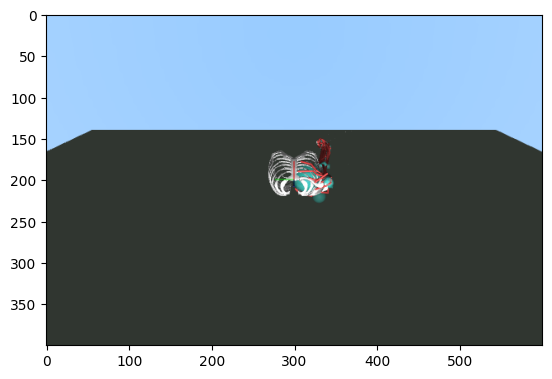

In [5]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Simulation

If model.opt.timestep is big, the simulation not works well. 

When you want to control multipl joints, you need to set the model.opt.timestep with smaller value.

In case of controlling 20 joints including independent and dependent joints, You need to set the timestep as 0.0001

In [6]:
model.opt.timestep = 0.0001

In [7]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
for joint_name in interest_joint_map:
    joint_i = interest_joint_map[joint_name]["joint_id"]
    final_goal_qpos[joint_i] = interest_joint_map[joint_name]["goal_angle"]
    
# Simulation params
n_times = 10000
kp = 500.0  # Stiffness
kv = 50.0   # Damping

# Simulation Constants
times = np.arange(n_times) * model.opt.timestep

# Result dummy
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)
qpos_traj = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
qpos_traj.columns = ["time"] + joint_names
qforces = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
qforces.columns = ["time"] + joint_names
qerrors = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
qerrors.columns = ["time"] + joint_names

interest_joint_ids = [interest_joint_map[name]["joint_id"] for name in interest_joint_names]
interest_joint_ids = np.array(interest_joint_ids)

# Simulation
for time_i in tqdm(range(n_times)):
    time = times[time_i]
    
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    goal_qpos = mj_data.qpos.copy()
    error_q = np.zeros_like(goal_qpos)
    error_q[interest_joint_ids] = final_goal_qpos[interest_joint_ids] - current_qpos[interest_joint_ids]
    
    error_v = np.zeros_like(goal_qpos)
    error_v[interest_joint_ids] = 0 - current_qvel[interest_joint_ids]
    
    # Force
    tau_all = np.zeros(model.nv)
    tau_all = kp * error_q + kv * error_v
    mj_data.qfrc_applied[:] = tau_all

    # Save
    qpos_traj.iloc[time_i] = np.hstack([time, current_qpos])
    qerrors.iloc[time_i] = np.hstack([time, error_q])
    qforces.iloc[time_i] = np.hstack([time, tau_all])
    
    # Forward dyanmics
    mujoco.mj_step(model, mj_data)   
    
    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|██████████| 10000/10000 [00:39<00:00, 251.13it/s]


In [8]:
mediapy.show_video(pixels, fps = 30)

This browser does not support the video tag.


# Qpos plot

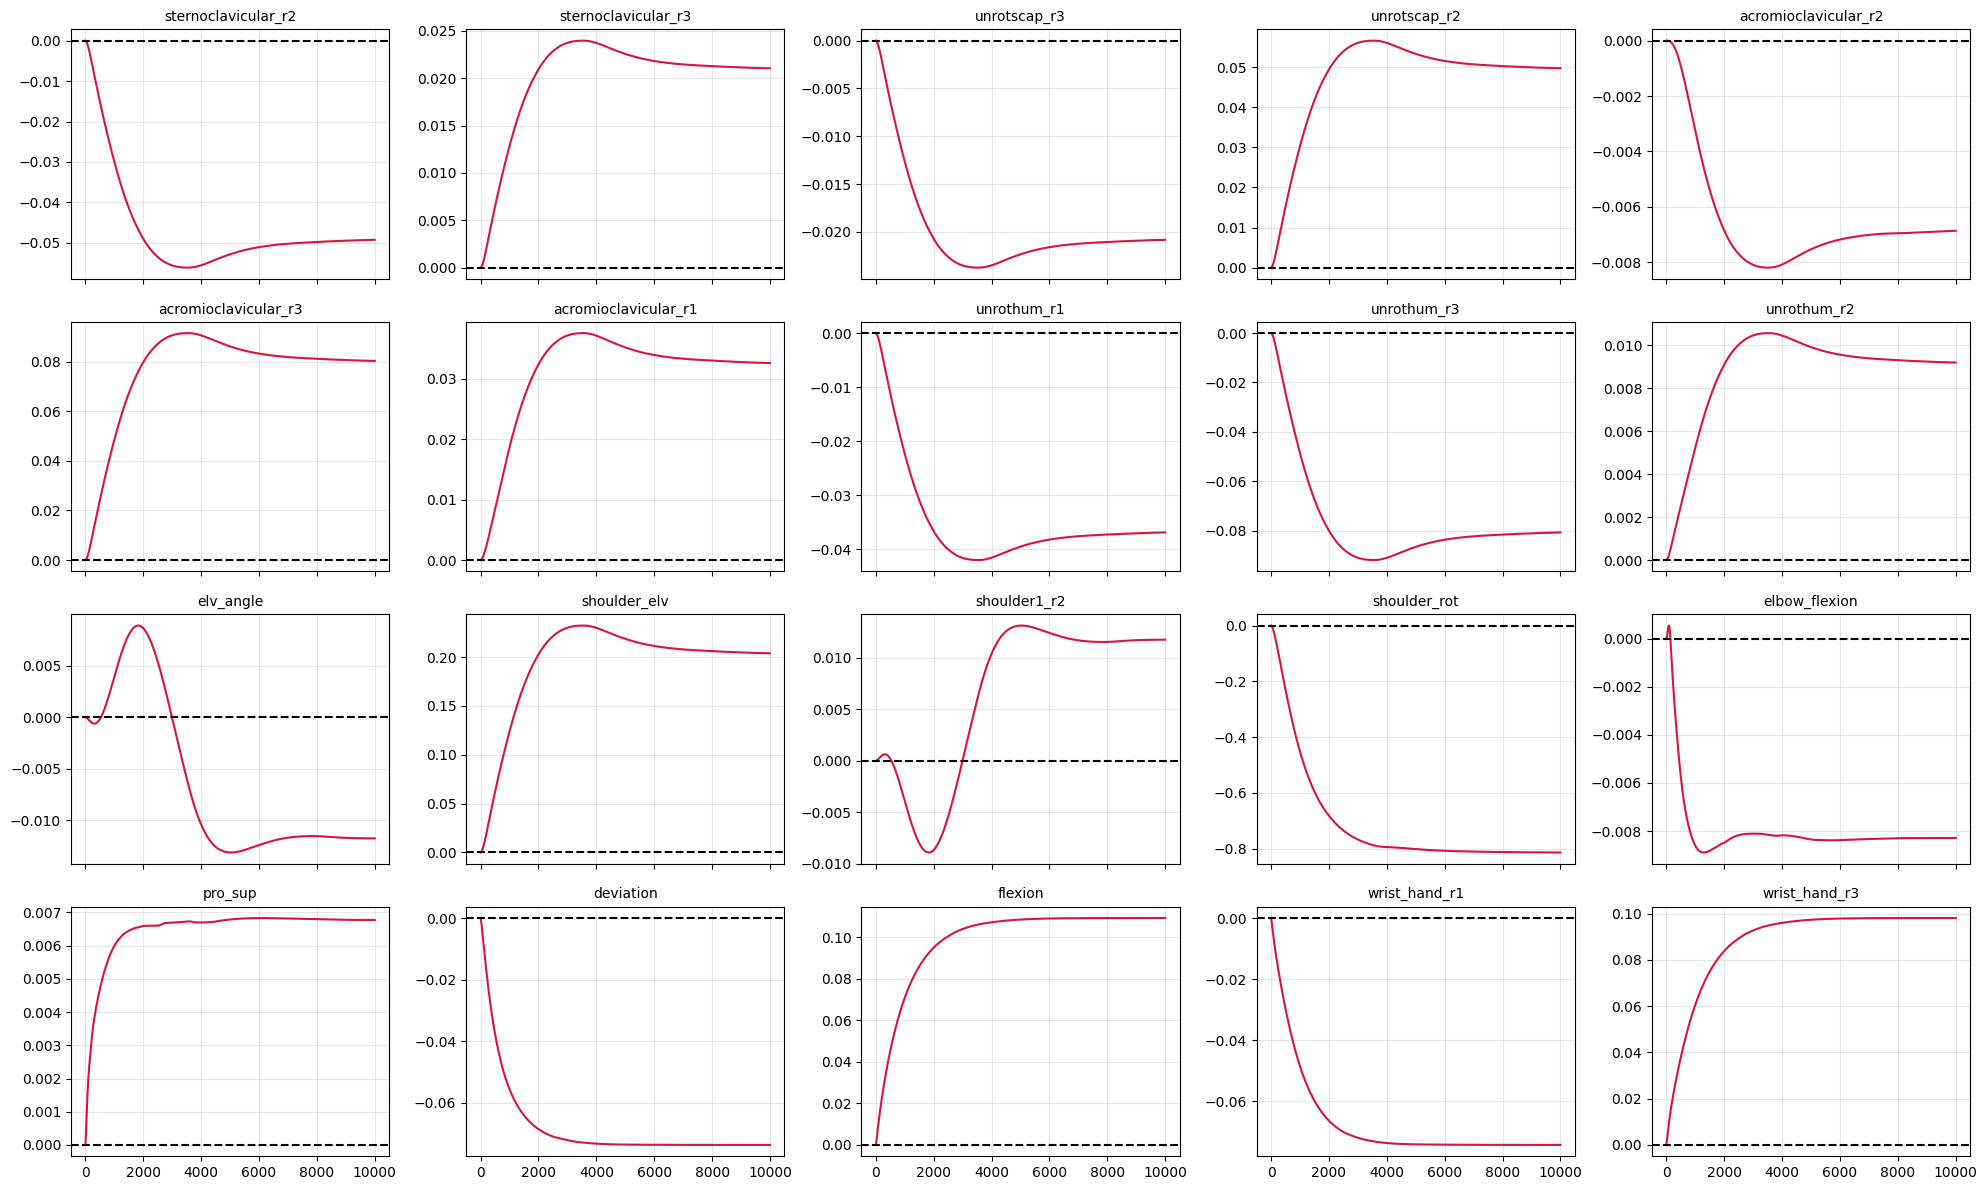

In [22]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    xs = qpos_traj[joint_name].index
    ax.plot(qpos_traj[joint_name], color = "crimson", lw = 1.5)
    ax.axhline(y = goal_angle_map[joint_name], xmin = xs.min(), xmax = xs.max(), color = "black", linestyle = "--")
    ax.set_title(joint_name, fontsize = 10)
    ax.grid(alpha = 0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Error plot

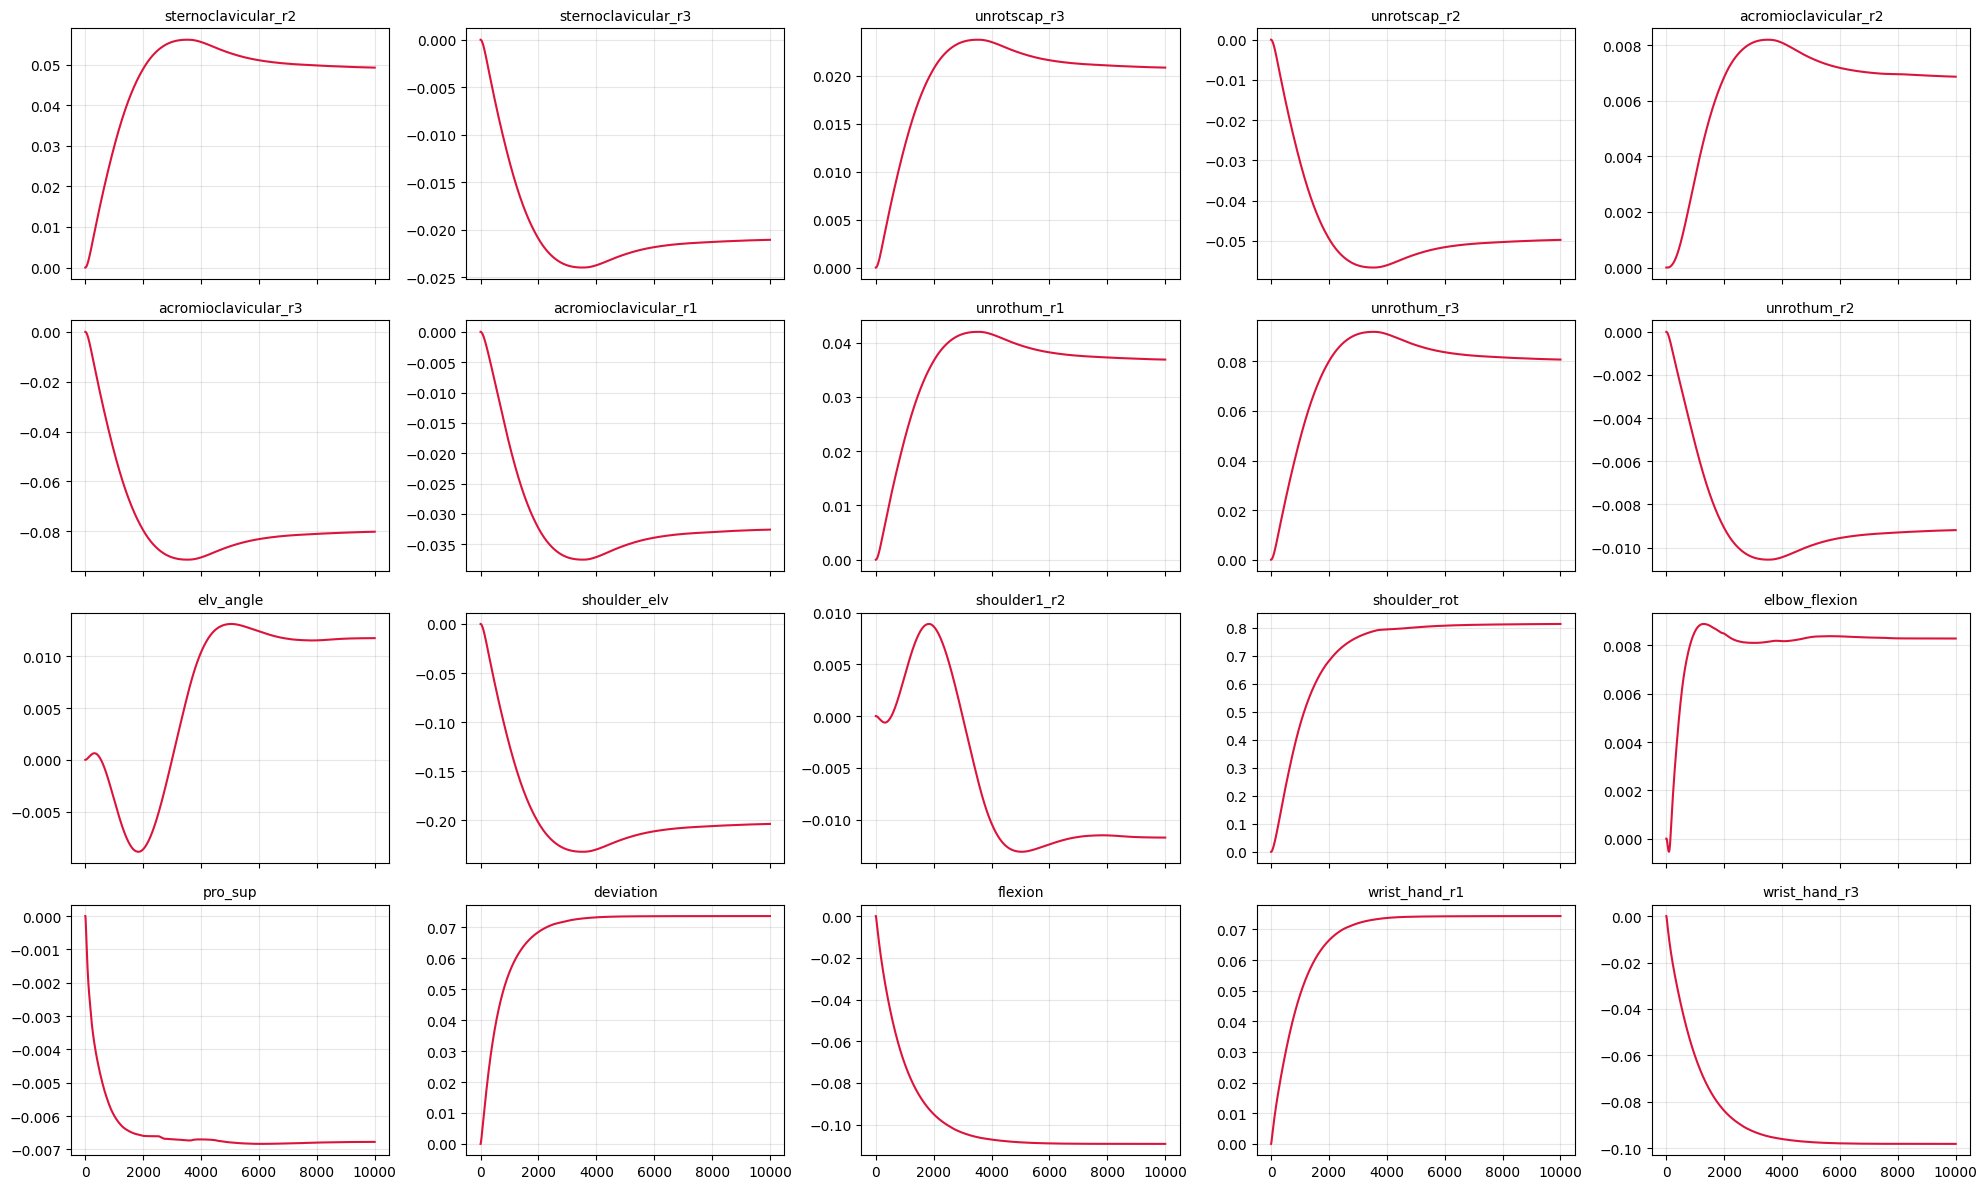

In [9]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(qerrors[joint_name], color='crimson', lw=1.5)
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Force plot

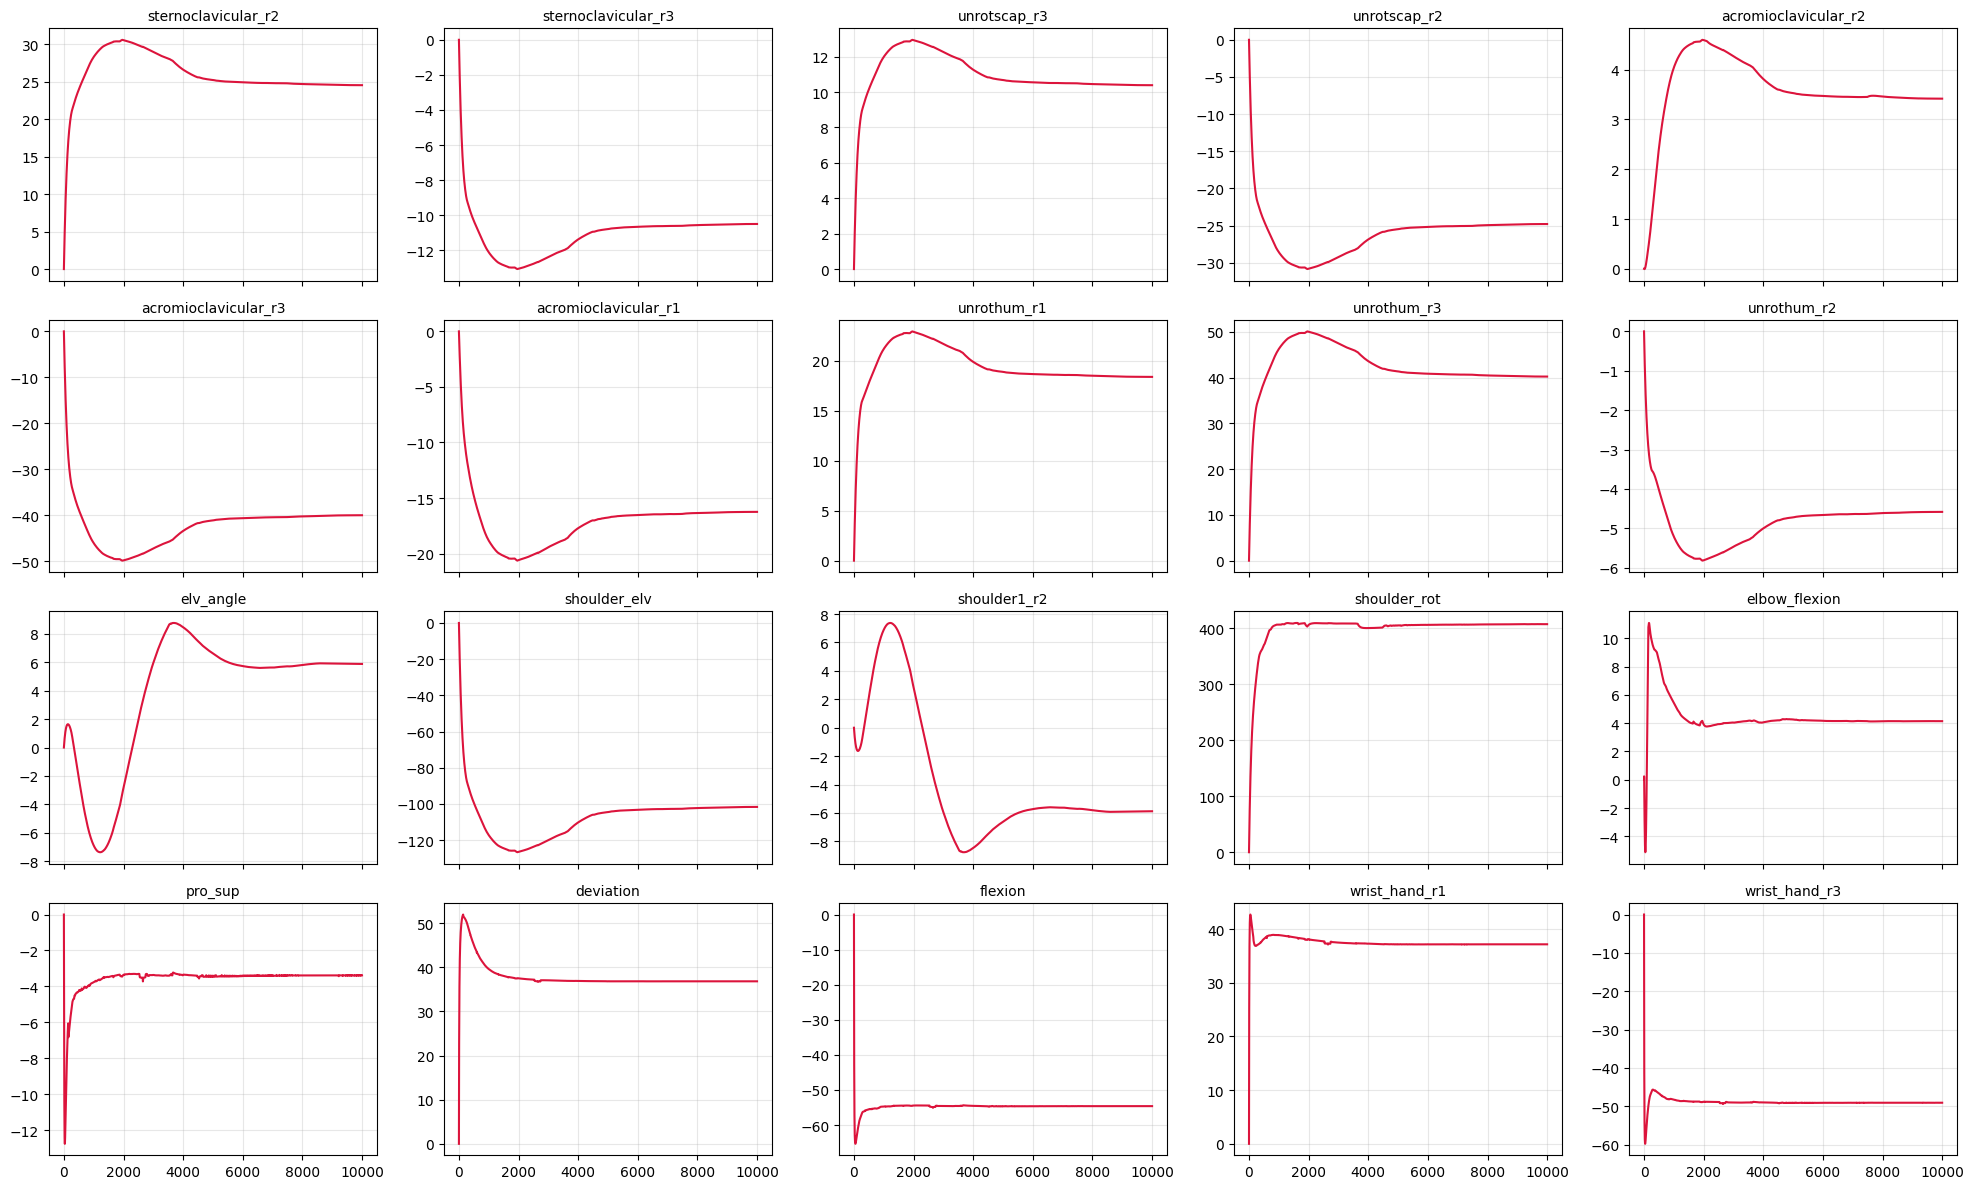

In [13]:
# Data
qforces_nonZero = qforces.loc[:, (qforces != 0).any(axis=0)]

# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(qforces_nonZero[joint_name], color='crimson', lw=1.5)
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()